In [59]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from langgraph.graph import MessagesState,StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage

In [60]:
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.1-8b-instant")
llm.invoke("hi").content

'Hello. How can I assist you today?'

In [61]:
tavily_tool = TavilySearchResults()

In [5]:
tavily_tool.invoke("What is the capital of France?")

[{'url': 'https://www.ebsco.com/research-starters/geography-and-cartography/paris-france',
  'content': 'Browse Subject Areas\n\n# Paris, France\n\nParis, the capital of France, is renowned globally for its iconic landmarks such as the Eiffel Tower, the Louvre Museum, and Notre-Dame Cathedral. This vibrant city, located along the Seine River in the Île de France region, is divided into 20 arrondissements, each with its unique character and cultural significance. Paris is not only a historical epicenter but also a major hub for international fashion, attracting millions of tourists each year—over 40 million in 2022—who come to experience its art, cuisine, and diverse attractions. [...] ## Paris, France\n\nParis is the capital of France and is known throughout the world as the home of such attractions as the Louvre Museum, the Eiffel Tower, and Notre-Dame Cathedral. It is also internationally recognized as a center for the international fashion industry.\n\n## Landscape\n\nThe Paris metr

In [6]:
results = tavily_tool.run("latest news on AI")
print(results)

[{'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates', 'content': 'Summary: A new study from Microsoft Research, detailed in Fortune, identifies the specific career paths most "exposed" to the next wave of generative AI and autonomous agents. The research suggests that high-skill, white-collar roles, particularly those in finance, legal services, and software engineering, face the highest degree of task automation. Unlike previous industrial shifts that impacted manual labor, this AI wave is increasingly capable of performing complex cognitive tasks such as contract analysis, code debugging, and financial forecasting. Microsoft researchers emphasize that "exposure" does not necessarily mean total job replacement, but rather a fundamental restructuring of daily responsibilities where workers must adapt to collaborating with AI to remain competitive. [...] Summary: A former Google software engineer has been convicted on multiple counts of trade secret theft after a federal 

In [62]:
@tool
def get_city_details(city_name: str):
    "Should do a web search to find the required city details"
    response = tavily_tool.invoke(city_name)
    return response

In [63]:
tools = [get_city_details]

In [64]:
model_with_tools = llm.bind_tools(tools)

In [65]:
class CityDetails(BaseModel):
    """Respond to the user with this"""
    state_name: str = Field(description="State name of the city")
    state_capital: str = Field(description="State capital of the city")
    country_name: str = Field(description="Country name of the city")
    country_capital: str = Field(description="Country capital of the city")

In [66]:
model_with_structured_output = llm.with_structured_output(CityDetails)

In [67]:
# Inherit 'messages' key from MessagesState, which is a list of chat messages
class AgentState(MessagesState):
    # Final structured response from the agent
    final_response: CityDetails

In [70]:
def call_model(state: AgentState):
    print(f" this is 01 input from call model {state}")
    response = model_with_tools.invoke(state['messages'])
    print(f"this is 02 response from call model  {response}")
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [71]:
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    
    # If there is no function call, then we respond to the user
    if not last_message.tool_calls:
        return "respond"
    # Otherwise if there is, we continue with the tool
    else:
        return "continue"

In [72]:
def respond(state: AgentState):
    print(f"here is 03 state from respond {state}")
    response = model_with_structured_output.invoke([HumanMessage(content=state['messages'][-1].content)])
    # We return the final answer
    print(f"this is 04 response from respond{response}")
    return {"final_response": response}

In [73]:
# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("llm", call_model)
workflow.add_node("tools", ToolNode(tools=tools))
workflow.add_node("respond", respond)

workflow.set_entry_point("llm")

workflow.add_conditional_edges("llm", should_continue, {
    "continue": "tools", "respond": "respond",})

workflow.add_edge("tools", "llm")
workflow.add_edge("respond", END)
graph = workflow.compile()

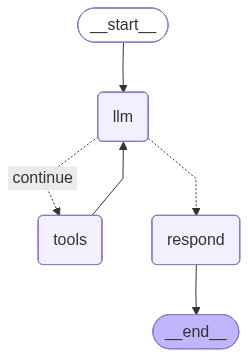

In [74]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [75]:
answer = graph.invoke(input={"messages": [("human", "Tell me about the city details for Lucknow?")]})

 this is 01 input from call model {'messages': [HumanMessage(content='Tell me about the city details for Lucknow?', id='fccfca1f-69cb-4c21-b21e-d4bba748c49b')]}
this is 02 response from call model  content='' additional_kwargs={'tool_calls': [{'id': 'kydz2x39f', 'function': {'arguments': '{"city_name":"Lucknow"}', 'name': 'get_city_details'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 236, 'total_tokens': 253, 'completion_time': 0.01996339, 'completion_tokens_details': None, 'prompt_time': 0.013821781, 'prompt_tokens_details': None, 'queue_time': 0.047241969, 'total_time': 0.033785171}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-a6eedfac-c741-49c0-ba46-961f62be0b9d-0' tool_calls=[{'name': 'get_city_details', 'args': {'city_name': 'Lucknow'}, 'id': 'kydz2x39f', 'type': 'tool_call'}] usage_metadata={'input_tokens': 236, 'output_tokens': 17, 't

In [77]:
for m in answer['messages']:
    m.pretty_print()

================================ Human Message =================================

Tell me about the city details for Lucknow?
================================== Ai Message ==================================
Tool Calls:
  get_city_details (kydz2x39f)
 Call ID: kydz2x39f
  Args:
    city_name: Lucknow
================================= Tool Message =================================
Name: get_city_details

[{"url": "https://en.wikipedia.org/wiki/Lucknow", "content": "Lucknow (Hindi: Lakhanaū, pronounced (/wiki/Help:IPA/Hindi_and_Urdu \"Help:IPA/Hindi and Urdu\") ⓘ) is a metropolis and the second largest city of the Indian state of Uttar Pradesh where it serves as the capital and the administrative headquarters of the eponymous district and division. The city had a population of 2.8 million according to the 2011 census making it the eleventh most populous city and the twelfth-most populous urban agglomeration of India. It is an important centre of education, commerce, aerospace, finance, ph

In [57]:

structured_output = answer["final_response"]

In [58]:

structured_output

CityDetails(state_name='Uttar Pradesh', state_capital='Lucknow', country_name='India', country_capital='New Delhi')